In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import dask_geopandas
import json
from glob import glob
import time

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
%%time
dataset = 'ne_10m_admin0_countries'
collection_id = 'vector-ne-10m-admin0-countries'

# Stac collection title
collection_title = 'Natural Earth Countries'

# Stac collection description
description = '''Natural Earth (ne) Admin 0 (contry-level) data.'''

# Parquet file custom metadata
custom_meta_content = {'About': description}

dt_col = 'timestamp'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'ADM0_A3'
dimension_values = {}

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 26
target_level = 14
max_depth = 14
max_inflation = 100 #None
target_rows = 1e6

grid = nestedgrid.World(4326)
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore.Vectorstore(
    dataset=dataset,
    collection_id=collection_id,
    dimension_values=dimension_values,
    grid=grid,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    max_inflation=max_inflation,
    target_rows=target_rows,
    custom_meta_content=custom_meta_content,
    verbose=True,
)

vs.write_metadata()
vs.read_metadata()

filepath = '/data/vector/ne_10m_cultural/10m_cultural/ne_10m_admin_0_countries.shp'
gdf_complete = geopandas.read_file(filepath)
gdf_complete[dt_col] = datetime(2022, 5, 12, tzinfo=pytz.utc)

assert(~gdf_complete[id_col].duplicated().any())

gdf_complete.tail(2)

CPU times: total: 1.31 s
Wall time: 2.23 s


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,timestamp
256,Admin-0 country,6,5,Serranilla Bank,SER,0,2,Indeterminate,1,Serranilla Bank,...,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,"POLYGON ((-78.63707 15.86209, -78.64041 15.864...",2022-05-12 00:00:00+00:00
257,Admin-0 country,6,6,Scarborough Reef,SCR,0,2,Indeterminate,1,Scarborough Reef,...,None,None,None,None,None,None,None,None,"POLYGON ((117.75389 15.15437, 117.75569 15.151...",2022-05-12 00:00:00+00:00


In [3]:
vars(vs)

{'grid': World(4326),
 'morton': <qtree_index.mortoncurve.Morton at 0x22f6709ff90>,
 'valid_range': <POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))>,
 'dataset': 'ne_10m_admin0_countries',
 'collection_id': 'vector-ne-10m-admin0-countries',
 'temporal_levels': [],
 'dimension_values': {},
 'vectorstore_directory': 'data/vectorstore/',
 'dataset_directory': 'data/vectorstore/ne_10m_admin0_countries',
 'grid_directory': 'data/vectorstore/ne_10m_admin0_countries/grid=World(4326)',
 'geoparquet_directory': 'data/vectorstore/ne_10m_admin0_countries/grid=World(4326)/geoparquet',
 'index_directory': 'data/vectorstore/ne_10m_admin0_countries/grid=World(4326)/index',
 'dt_col': 'timestamp',
 'key_col': '_root',
 'idx_col': '_idx',
 'geom_col': 'geometry',
 'id_col': 'ADM0_A3',
 'idx_box_col': 'idx_bounds',
 'geom_area_col': '_geom_area',
 'geom_length_col': '_geom_length',
 'primary_keys': ['timestamp', 'ADM0_A3'],
 'max_level': 26,
 'target_level': 14,
 'max_depth': 14,
 'max_inflatio

# Chunked successive ingestion

In [4]:
%%time
n_chunks = 1
for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
    print('Chunk', i)
    vs.partial_upload(
        chunk,
        defrag=False,
        index=False,
        geometry_area=False,
        geometry_length=False,
    )

Chunk 0
df_root 258
Time for indexing the root of each unique geometry in seconds 0.015
cannot call `vectorize` on size 0 inputs unless `otypes` is set
Failed to use numpy. Switching to pandas
distributed over 1 partitions
Time for creating partitions in seconds 0.038
Time for writing GeoDataFrame to GeoParquet partitions 0.142
CPU times: total: 141 ms
Wall time: 176 ms


C:\Users\2D1245897\software\openeo\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\2D1245897\software\openeo\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)


In [5]:
%%time
vs.unify_schemas()

Time for unify_schemas 0.08
CPU times: total: 15.6 ms
Wall time: 80.4 ms


In [6]:
%%time
vs.defrag()

Time for defragging 0.3
CPU times: total: 109 ms
Wall time: 300 ms


In [7]:
%%time
vs.repartition({})

level 0
source partition          target partition          records stay    records move   
level 1
source partition          target partition          records stay    records move   
level 2
source partition          target partition          records stay    records move   
level 3
source partition          target partition          records stay    records move   
level 4
source partition          target partition          records stay    records move   
level 5
source partition          target partition          records stay    records move   
level 6
source partition          target partition          records stay    records move   
level 7
source partition          target partition          records stay    records move   
level 8
source partition          target partition          records stay    records move   
level 9
source partition          target partition          records stay    records move   
level 10
source partition          target partition          records stay    rec

In [8]:
%%time
vs.defrag()

Time for defragging 0.24
CPU times: total: 125 ms
Wall time: 240 ms


In [9]:
# %%time
# vs.reindex({})

# Visualize spatial partitions

In [10]:
%%time
ddf = dask_geopandas.read_parquet(vs.geoparquet_directory)
ddf

CPU times: total: 15.6 ms
Wall time: 50.4 ms


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,ADM0_A3,GEOU_DIF,GEOUNIT,GU_A3,SU_DIF,SUBUNIT,SU_A3,BRK_DIFF,NAME,NAME_LONG,BRK_A3,BRK_NAME,BRK_GROUP,ABBREV,POSTAL,FORMAL_EN,FORMAL_FR,NAME_CIAWF,NOTE_ADM0,NOTE_BRK,NAME_SORT,NAME_ALT,MAPCOLOR7,MAPCOLOR8,MAPCOLOR9,MAPCOLOR13,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,INCOME_GRP,FIPS_10,ISO_A2,ISO_A2_EH,ISO_A3,ISO_A3_EH,ISO_N3,ISO_N3_EH,UN_A3,WB_A2,WB_A3,WOE_ID,WOE_ID_EH,WOE_NOTE,ADM0_ISO,ADM0_DIFF,ADM0_TLC,ADM0_A3_US,ADM0_A3_FR,ADM0_A3_RU,ADM0_A3_ES,ADM0_A3_CN,ADM0_A3_TW,ADM0_A3_IN,ADM0_A3_NP,ADM0_A3_PK,ADM0_A3_DE,ADM0_A3_GB,ADM0_A3_BR,ADM0_A3_IL,ADM0_A3_PS,ADM0_A3_SA,ADM0_A3_EG,ADM0_A3_MA,ADM0_A3_PT,ADM0_A3_AR,ADM0_A3_JP,ADM0_A3_KO,ADM0_A3_VN,ADM0_A3_TR,ADM0_A3_ID,ADM0_A3_PL,ADM0_A3_GR,ADM0_A3_IT,ADM0_A3_NL,ADM0_A3_SE,ADM0_A3_BD,ADM0_A3_UA,ADM0_A3_UN,ADM0_A3_WB,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,LABEL_X,LABEL_Y,NE_ID,WIKIDATAID,NAME_AR,NAME_BN,NAME_DE,NAME_EN,NAME_ES,NAME_FA,NAME_FR,NAME_EL,NAME_HE,NAME_HI,NAME_HU,NAME_ID,NAME_IT,NAME_JA,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_UK,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,TLC_DIFF,FCLASS_TLC,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,timestamp,_root,grid,spatial_partition
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,object,int64,int64,object,object,int64,int64,object,object,object,object,int64,object,object,int64,object,object,int64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,int64,int64,int64,int64,float64,int64,int64,int64,int64,object,object,object,object,object,object,object,object,object,object,object,object,int64,int64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,int64,int64,object,object,object,object,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,int64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,geometry,"datetime64[us, UTC]",object,category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


<Axes: >

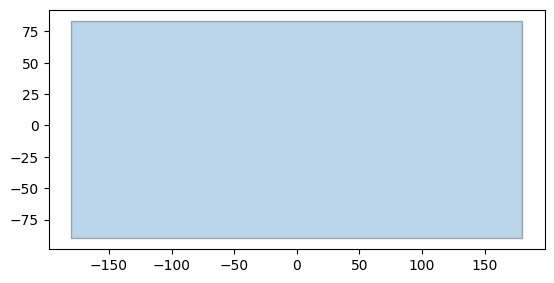

In [11]:
ddf.spatial_partitions.plot(edgecolor='k', alpha=0.3)

# Upload to COS and register in STAC

In [12]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('claimed_access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('claimed_secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('claimed_endpoint_url', '')
# S3 access url
private_endpoint_url = os.getenv('claimed_private_endpoint_url', '')
# S3 bucket
bucket = os.getenv('claimed_bucket', '')

# STAC url
stac_url = os.getenv('stac_url', 'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com')
# STAC certificate
certificate = os.getenv('certificate', '/opt/app-root/src/ca.cert.txt')

#vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

In [13]:
# vs.access_key_id = access_key_id
# vs.secret_access_key = secret_access_key
# vs.endpoint_url = endpoint_url
# vs.bucket = bucket
# vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

# storage_urls = vs.remote_fs.glob(os.path.join(vs.remote_geoparquet_directory, '**.parquet').replace('\\', '/'))
# storage_urls

In [14]:
# # GeoDN username
# geodn_username = os.getenv('geodn_username', '')
# # GeoDN password
# geodn_password = os.getenv('geodn_password', '')
# # GeoDN url
# GEODN_URL = os.getenv('GEODN_URL', "https://openeo-geodn-nasageospatial-dev.cash.sl.cloud9.ibm.com/openeo/1.1.0/")

In [15]:
stac_json_folder = os.path.join(vs.grid_directory, 'stac').replace('\\','/')

bbox = vs.grid.valid_bounds_wgs84
df = pandas.read_parquet(vs.geoparquet_directory, columns=[vs.dt_col])
dt_start = df[vs.dt_col].min()
dt_end = df[vs.dt_col].max()

vs.to_stac_collection(
    stac_url,
    vs.collection_id,
    collection_title,
    stac_json_folder,
    certificate,
    bbox,
    dt_start,
    dt_end,
    description,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
)

In [16]:
%%time
# Upload to COS
upload_type = "replace_all" #"replace_all" "replace_partition" "add" "stac_items_only"
vs.to_cos(
    upload_type=upload_type,
    stac_url=stac_url,
    collection_id=vs.collection_id,
    collection_title=collection_title,
    stac_json_folder=stac_json_folder,
    certificate=certificate,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
    temporal_partitions=None,
    spatial_partitions=None,
)

uploading to remote_path claimed-test/vectorstore/ne_10m_admin0_countries/grid=World(4326)/geoparquet/spatial_partition=0q/a26333f6ebcc486f9e82bfd3881873bc.parquet
schema.names ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3

In [17]:
vs.stac_json_folder_submitted

'data/vectorstore/ne_10m_admin0_countries/grid=World(4326)/stac/submitted'

In [18]:
vs.stac_url

'https://stac-fastapi-sqlalchemy-nasageospatial-dev.cash.sl.cloud9.ibm.com'

In [19]:
vs.collection_id

'vector-ne-10m-admin0-countries'